# Module 1 - Fluorouracil: Exploratory Data Analysis

This notebook performs deeper EDA on the fluorouracil dataset established in `01_5fu_explore.ipynb`.  
The focus shifts from data inventory to analytical findings: adverse reaction profiles, serious outcome distributions, cross-regimen comparisons, and demographic context.

Data was filtered to PS/SS role codes and IV formulations only — see Step 8 of `01_5fu_explore.ipynb` for rationale.

**Prerequisite:** Run `01_5fu_explore.ipynb` first to ensure the `fluorouracil_analysis` table exists in the database.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

db_path = r"C:\Users\palla\OneDrive\Documents\Coding Projects\FDA_FAERS\database\faers.db"
conn = sqlite3.connect(db_path)

In [2]:
FU_analysis = pd.read_sql_query("SELECT * FROM fluorouracil_analysis", conn)
print(f'fluorouracil_analysis: {FU_analysis.shape[0]:,} records, {FU_analysis["primaryid"].nunique():,} unique reports')

fluorouracil_analysis: 10,349 records, 5,617 unique reports


## Section 1 - Adverse Reaction Profile

What are the most commonly reported adverse events across all fluorouracil-containing reports in the analysis dataset? Reactions are pulled from the `reac` table and joined to `fluorouracil_analysis` on `primaryid`.

In [3]:
reactions = pd.read_sql_query("""
SELECT
    r.pt AS symptom,
    COUNT(*) AS symptom_count
FROM reac r
JOIN (SELECT DISTINCT primaryid FROM fluorouracil_analysis) f
    ON r.primaryid = f.primaryid
GROUP BY r.pt
ORDER BY symptom_count DESC
""", conn)

reactions.head(20)

,symptom,symptom_count
0,Diarrhoea,676
1,Neutropenia,521
2,Off label use,507
3,Nausea,409
4,Disease progression,376
5,Drug ineffective,339
6,Thrombocytopenia,326
7,Neuropathy peripheral,311
8,Vomiting,304
9,Febrile neutropenia,290


## Section 2 - Adverse Reactions by Drug Combination

How does the adverse reaction profile differ across fluorouracil-containing regimens? Each combination is compared side-by-side and visualized as a normalized heatmap.

**Note on role_cod filtering:** Unlike Section 1, this query uses the raw `drug` table without restricting to PS/SS role codes. Named combination regimens like FOLFOX and FOLFIRI show a known FAERS reporting pattern where reporters list individual component drugs (fluorouracil, oxaliplatin, irinotecan) as primary suspects while recording the combination string as concomitant for the same patient. Applying a PS/SS filter to combination drugnames would discard the majority of valid records due to this reporting artifact rather than actual causality. The specific drugname filter is sufficient here.

In [4]:
reactions_for_combos = pd.read_sql_query(r"""
SELECT
    r.pt AS symptom,

    COUNT(DISTINCT CASE WHEN d.drugname = 'FLUOROURACIL' THEN r.primaryid END)
        AS fluorouracil_count,

    COUNT(DISTINCT CASE WHEN d.drugname = 'FLUOROURACIL\LEUCOVORIN CALCIUM\OXALIPLATIN' THEN r.primaryid END)
        AS folfox_count,

    COUNT(DISTINCT CASE WHEN d.drugname = 'FLUOROURACIL\IRINOTECAN\LEUCOVORIN' THEN r.primaryid END)
        AS folfiri_count,

    COUNT(DISTINCT CASE WHEN d.drugname = 'FLUOROURACIL SODIUM' THEN r.primaryid END)
        AS fu_sodium_count,

    COUNT(DISTINCT CASE WHEN d.drugname = 'FLUOROURACIL\IRINOTECAN\LEUCOVORIN\OXALIPLATIN' THEN r.primaryid END)
        AS folfirinox_count

FROM reac r
JOIN drug d ON r.primaryid = d.primaryid
WHERE d.drugname IN (
    'FLUOROURACIL',
    'FLUOROURACIL\LEUCOVORIN CALCIUM\OXALIPLATIN',
    'FLUOROURACIL\IRINOTECAN\LEUCOVORIN',
    'FLUOROURACIL SODIUM',
    'FLUOROURACIL\IRINOTECAN\LEUCOVORIN\OXALIPLATIN'
)
GROUP BY r.pt
ORDER BY fluorouracil_count DESC
""", conn)

reactions_for_combos.head(20)

,symptom,fluorouracil_count,folfox_count,folfiri_count,fu_sodium_count,folfirinox_count
0,Diarrhoea,640,8,7,7,6
1,Off label use,538,21,22,12,6
2,Neutropenia,446,6,7,2,4
3,Nausea,410,9,3,6,3
4,Neuropathy peripheral,335,10,6,1,4
5,Drug ineffective,328,6,3,2,1
6,Disease progression,316,5,8,7,3
7,Vomiting,292,3,2,3,3
8,Thrombocytopenia,285,9,10,5,2
9,Fatigue,284,11,2,5,2


### Adverse Reaction Definitions

| Reaction | Definition |
|----------|------------|
| Diarrhoea | Frequent loose or watery stools |
| Off label use | Drug used outside its approved indication |
| Neutropenia | Low neutrophil count (increased infection risk) |
| Nausea | Sensation of needing to vomit |
| Neuropathy peripheral | Nerve damage causing numbness/tingling in extremities |
| Drug ineffective | Treatment did not produce intended effect |
| Disease progression | Worsening or advancement of disease |
| Thrombocytopenia | Low platelet count (increased bleeding risk) |
| Fatigue | Extreme tiredness or lack of energy |
| Myelosuppression | Reduced bone marrow activity (fewer blood cells produced) |
| Anaemia | Low red blood cell count or haemoglobin |
| Febrile neutropenia | Fever combined with low neutrophil count (serious condition) |
| Acute kidney injury | Sudden decline in kidney function |
| Pyrexia | Fever |
| Asthenia | General physical weakness |

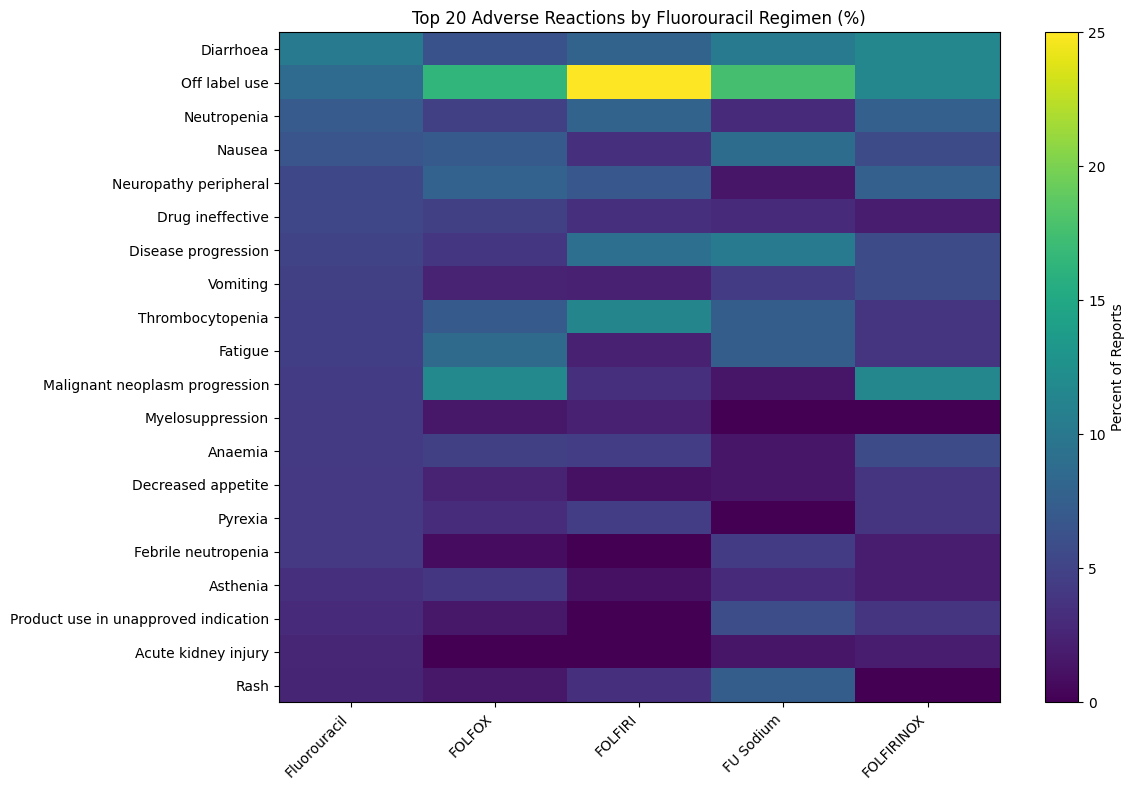

In [5]:
plot_df = reactions_for_combos.rename(columns={
    'fluorouracil_count': 'Fluorouracil',
    'folfox_count': 'FOLFOX',
    'folfiri_count': 'FOLFIRI',
    'fu_sodium_count': 'FU Sodium',
    'folfirinox_count': 'FOLFIRINOX'
})

heatmap_df = plot_df.set_index('symptom').head(20)
heatmap_pct = heatmap_df.div(heatmap_df.sum(axis=0), axis=1) * 100

plt.figure(figsize=(12, 8))
plt.imshow(heatmap_pct, aspect='auto')
plt.colorbar(label='Percent of Reports')
plt.xticks(range(len(heatmap_pct.columns)), heatmap_pct.columns, rotation=45, ha='right')
plt.yticks(range(len(heatmap_pct.index)), heatmap_pct.index)
plt.title('Top 20 Adverse Reactions by Fluorouracil Regimen (%)')
plt.tight_layout()
plt.show()